In [1]:
import sys
import torch

sys.path.insert(0, 'src')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Device: cuda


---
## Section 1 - VGG16 Architecture

In [2]:
from utils import load_vgg16, load_imagenet_classes
from section1 import count_parameters, classify, get_activation_maps, show_all_maps, show_activation_maps

vgg16 = load_vgg16()
classes = load_imagenet_classes()

In [3]:
# Q1: Parameter count
count_parameters(vgg16)

# Q2: Last layer output
print(f"  {vgg16.classifier[6]} -> {vgg16.classifier[6].out_features} outputs")

  Total: 138,357,544 | Conv: 14,714,688 (10.6%) | FC: 123,642,856 (89.4%)
  Linear(in_features=4096, out_features=1000, bias=True) -> 1000 outputs


In [4]:
# Q3: Classify images
import glob
for p in sorted(glob.glob('images/*.jpg')): classify(p, vgg16, classes)

First conv: (64, 224, 224)


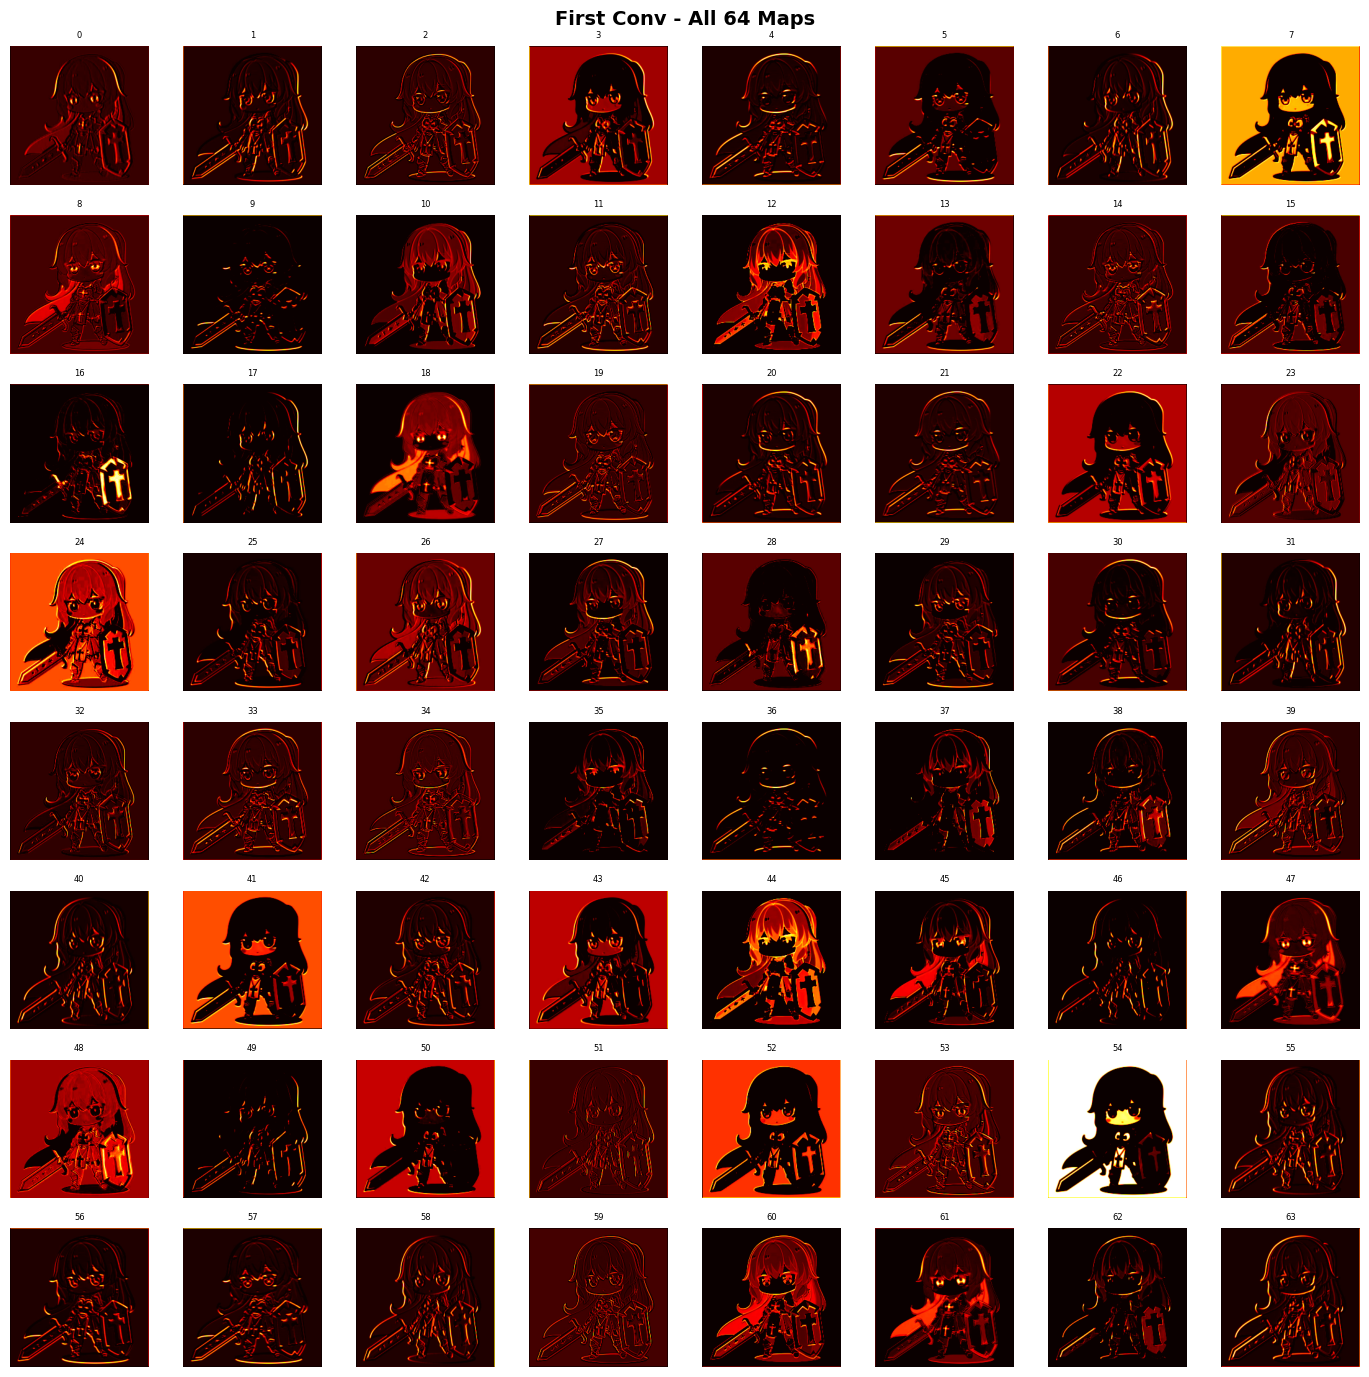

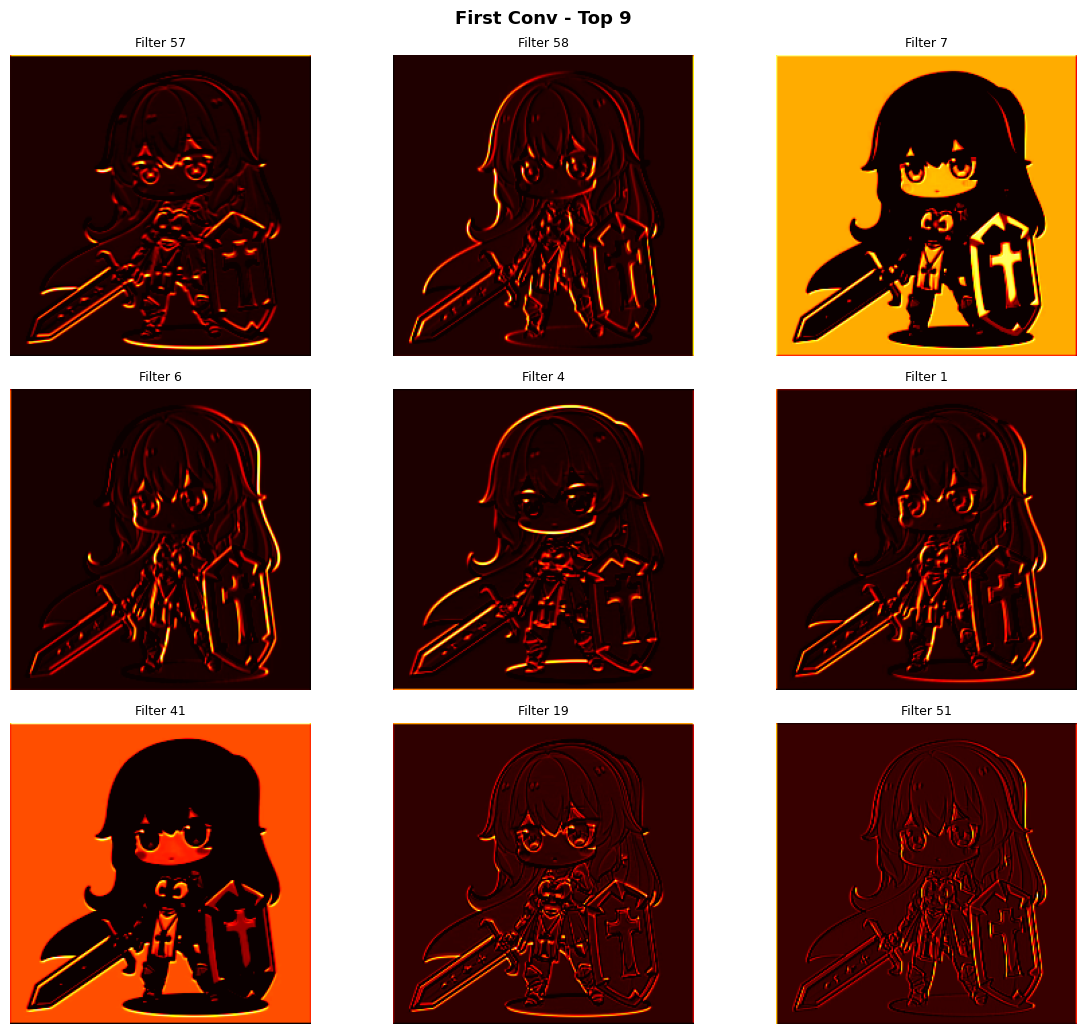

Deep layer: (512, 14, 14)


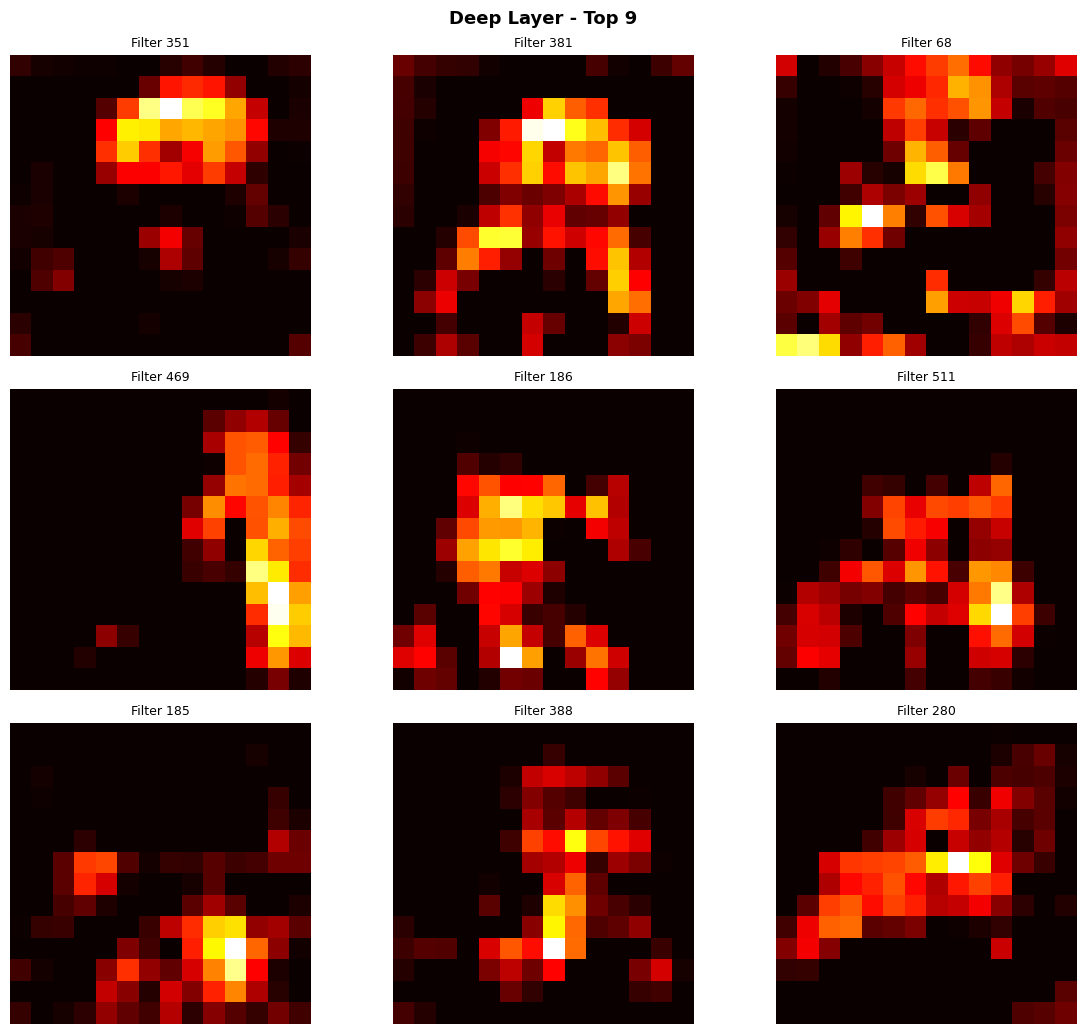

In [5]:
# Q4: Activation maps
img = 'data/test/paladin.jpg'

acts0 = get_activation_maps(vgg16, img, layer_index=0)
print(f"First conv: {acts0.shape}")
show_all_maps(acts0, 'First Conv - All 64 Maps')
show_activation_maps(acts0, 9, 'First Conv - Top 9')

acts_deep = get_activation_maps(vgg16, img, layer_index=24)
print(f"Deep layer: {acts_deep.shape}")
show_activation_maps(acts_deep, 9, 'Deep Layer - Top 9')

---
## Section 2 - Transfer Learning on 15-Scene

In [6]:
from section2 import VGG16relu7, load_15scene, extract_and_normalize, train_and_eval, plot_confusion

In [7]:
tr_p, y_tr, te_p, y_te, names = load_15scene('data/15-Scene')

  Dataset found (15 classes).
  00                   train:100  test:116
  01                   train:100  test:141
  02                   train:100  test:211
  03                   train:100  test:110
  04                   train:100  test:189
  05                   train:100  test:260
  06                   train:100  test:228
  07                   train:100  test:160
  08                   train:100  test:208
  09                   train:100  test:274
  10                   train:100  test:310
  11                   train:100  test:192
  12                   train:100  test:256
  13                   train:100  test:115
  14                   train:100  test:215
  Total: train:1500 test:2985


In [8]:
# 2.2 Feature extraction
ext = VGG16relu7(vgg16); ext.eval()

print("Train features:")
X_train = extract_and_normalize(tr_p, ext, device)
print(f"  shape: {X_train.shape}")

print("Test features:")
X_test = extract_and_normalize(te_p, ext, device)
print(f"  shape: {X_test.shape}")

Train features:
    320/1500
    640/1500
    960/1500
    1280/1500
  shape: (1500, 4096)
Test features:
    320/2985
    640/2985
    960/2985
    1280/2985
    1600/2985
    1920/2985
    2240/2985
    2560/2985
    2880/2985
  shape: (2985, 4096)


  C=1.0 -> Train:99.20%  Test:88.98%
              precision    recall  f1-score   support

          00       0.79      0.83      0.81       116
          01       0.92      1.00      0.96       141
          02       0.88      0.87      0.88       211
          03       0.89      0.93      0.91       110
          04       0.82      0.78      0.80       189
          05       0.86      0.92      0.89       260
          06       0.90      0.95      0.92       228
          07       0.90      0.93      0.91       160
          08       0.88      0.83      0.85       208
          09       0.93      0.93      0.93       274
          10       0.86      0.75      0.80       310
          11       0.93      0.90      0.91       192
          12       0.91      0.95      0.93       256
          13       0.87      0.95      0.91       115
          14       0.97      0.92      0.94       215

    accuracy                           0.89      2985
   macro avg       0.89      0.90      0.89

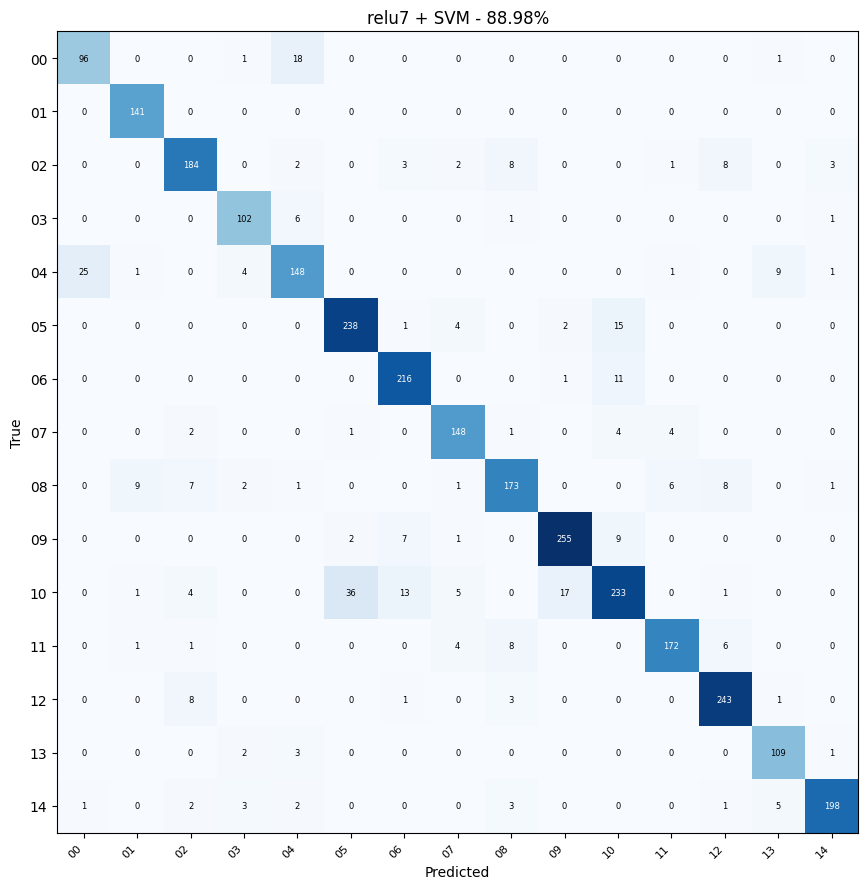

In [9]:
# 2.3 SVM
svm, acc, y_pred = train_and_eval(X_train, y_tr, X_test, y_te, C=1.0, class_names=names)
plot_confusion(y_te, y_pred, names, f'relu7 + SVM - {acc:.2%}')

---
## Section 2.4 - Going Further

In [10]:
from section2_4 import experiment_layers, experiment_C, experiment_resnet, experiment_finetune, experiment_pca

In [11]:
# 2.4.1 Layer comparison
layer_res = experiment_layers(tr_p, y_tr, te_p, y_te, device)

    320/1500
    640/1500
    960/1500
    1280/1500
    320/2985
    640/2985
    960/2985
    1280/2985
    1600/2985
    1920/2985
    2240/2985
    2560/2985
    2880/2985
  pool5   dim= 25088  acc=89.55%
    320/1500
    640/1500
    960/1500
    1280/1500
    320/2985
    640/2985
    960/2985
    1280/2985
    1600/2985
    1920/2985
    2240/2985
    2560/2985
    2880/2985
  relu6   dim=  4096  acc=90.55%
    320/1500
    640/1500
    960/1500
    1280/1500
    320/2985
    640/2985
    960/2985
    1280/2985
    1600/2985
    1920/2985
    2240/2985
    2560/2985
    2880/2985
  relu7   dim=  4096  acc=88.98%


  C=   0.001  Train:84.47%  Test:81.47%
  C=   0.010  Train:87.60%  Test:83.28%
  C=   0.100  Train:93.07%  Test:86.90%
  C=   0.500  Train:98.00%  Test:88.91%
  C=   1.000  Train:99.20%  Test:88.98%
  C=   5.000  Train:100.00%  Test:89.08%
  C=  10.000  Train:100.00%  Test:88.84%
  C= 100.000  Train:100.00%  Test:88.68%


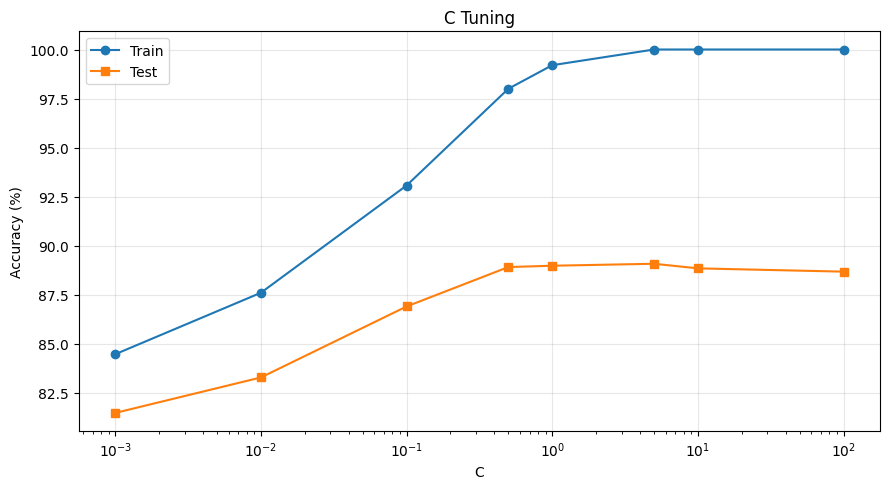

  Best C = 5.0 -> 89.08%


In [12]:
# 2.4.2 Tune C
best_C = experiment_C(X_train, y_tr, X_test, y_te)

In [13]:
# 2.4.3 ResNet50
resnet_acc = experiment_resnet(tr_p, y_tr, te_p, y_te, device, best_C)
print(f"  VGG16: {acc:.2%} vs ResNet50: {resnet_acc:.2%}")

    320/1500
    640/1500
    960/1500
    1280/1500
    320/2985
    640/2985
    960/2985
    1280/2985
    1600/2985
    1920/2985
    2240/2985
    2560/2985
    2880/2985
  ResNet50 (dim=2048) -> 91.83%
  VGG16: 88.98% vs ResNet50: 91.83%


  Ep  1/20 Loss:1.623 Train:55.27% Test:84.56%
  Ep  5/20 Loss:0.362 Train:89.87% Test:87.84%
  Ep 10/20 Loss:0.266 Train:92.67% Test:88.21%
  Ep 15/20 Loss:0.205 Train:94.53% Test:89.05%
  Ep 20/20 Loss:0.190 Train:94.87% Test:87.84%


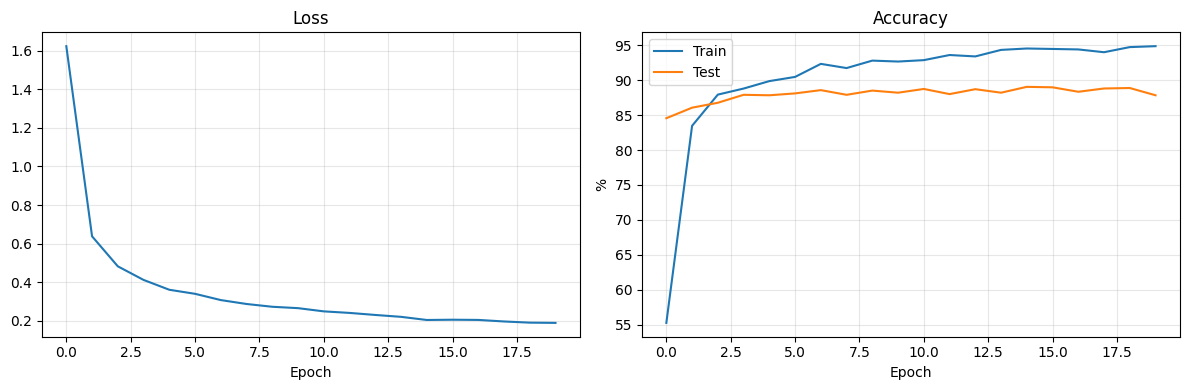

In [14]:
# 2.4.4 Fine-tune last layer
ft = experiment_finetune(tr_p, y_tr, te_p, y_te, n_classes=len(names), device=device)

In [15]:
# 2.4.5 PCA
from section2_4 import experiment_pca
pca_res = experiment_pca(X_train, y_tr, X_test, y_te, C=best_C)

  PCA(   64) var:67.8% acc:86.97%
  PCA(  128) var:77.0% acc:87.87%
  PCA(  256) var:85.0% acc:88.34%
  PCA(  512) var:92.6% acc:88.71%
  PCA( 1024) var:98.4% acc:89.01%
